# 📘 S4_P5 — Maisons (12 variables) : régression linéaire PUIS arbre de régression

## 🎯 Ce que tu vas apprendre
1. (Reprise complète de S2_P2) La régression multiple à 12 variables sur les prix des maisons
2. Ajouter un **arbre de régression** sur les mêmes données
3. Observer un arbre **grandir** de la profondeur 2 à 19 (boucle SuperTree) — et VOIR le surapprentissage arriver
4. Comprendre pourquoi ce notebook pèse 17 Mo ! (leçon pratique sur les widgets)

---
## Étape 1 — Charger tout le dataset
`housing_data = df` : les 13 colonnes (12 features + prix). Dataset pré-encodé (0/1 et échelle 0/0.5/1 pour furnishingstatus) — détails en S2_P2.

In [5]:
import pandas as pd 
import numpy as np

In [6]:
df = pd.read_csv("Housing_2.csv")
housing_data = df
housing_data

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1.0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1.0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0.5
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1.0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,0.0
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,0.5
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,0.0
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,1.0


Nuage area/price de référence (tendance montante + éventail — cf. S1_P2).

<Axes: xlabel='area', ylabel='price'>

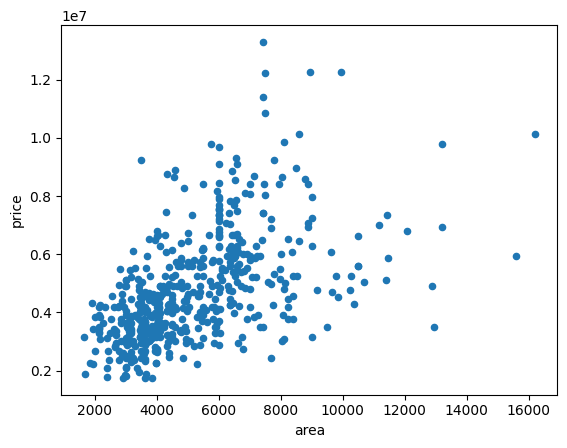

In [7]:
housing_data.plot.scatter(x="area", y ="price")

Exploration feature↔feature : area vs bedrooms (bandes horizontales, colinéarité potentielle — lecture détaillée en S2_P1/S2_P2, étape 2).

<Axes: xlabel='area', ylabel='bedrooms'>

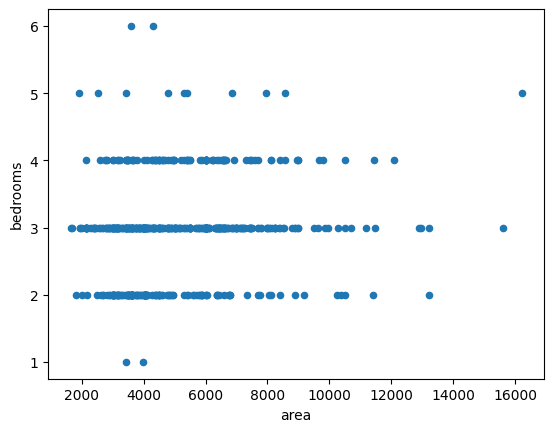

In [8]:
housing_data.plot.scatter(x="area", y ="bedrooms")

Idem avec bathrooms.

<Axes: xlabel='area', ylabel='bathrooms'>

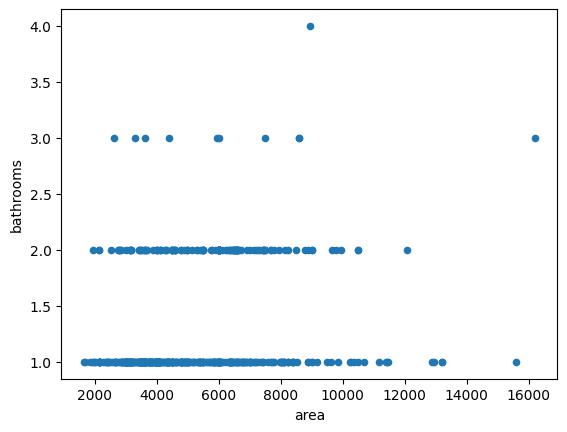

In [9]:
housing_data.plot.scatter(x="area", y ="bathrooms")

Idem avec prefarea (binaire → 2 lignes de points ; un boxplot serait plus lisible).

<Axes: xlabel='area', ylabel='prefarea'>

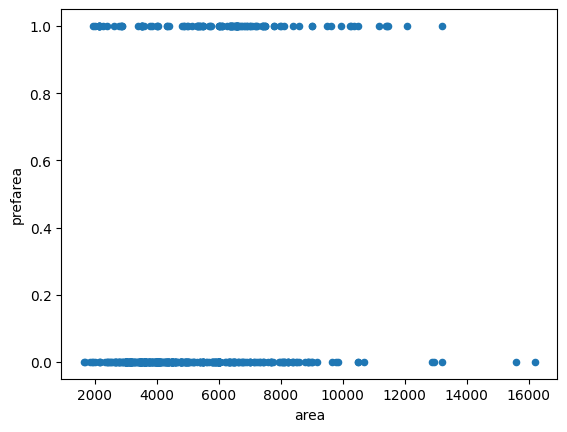

In [10]:
housing_data.plot.scatter(x="area", y ="prefarea")

Mise à l'échelle : prix en millions (⚠️ ne pas exécuter 2 fois — piège détaillé en S1_P2, étape 3).

In [11]:
housing_data["price"] = housing_data["price"]/1000000

Vérification (prix ~13.3).

In [12]:
housing_data.head(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13.300,7420,4,2,3,1,0,0,0,1,2,1,1.0
1,12.250,8960,4,4,4,1,0,0,0,1,3,0,1.0
2,12.250,9960,3,2,2,1,0,1,0,0,2,1,0.5
3,12.215,7500,4,2,2,1,0,1,0,1,3,1,1.0
4,11.410,7420,4,1,2,1,1,1,0,1,2,0,1.0


Version seaborn du nuage.

<Axes: xlabel='area', ylabel='price'>

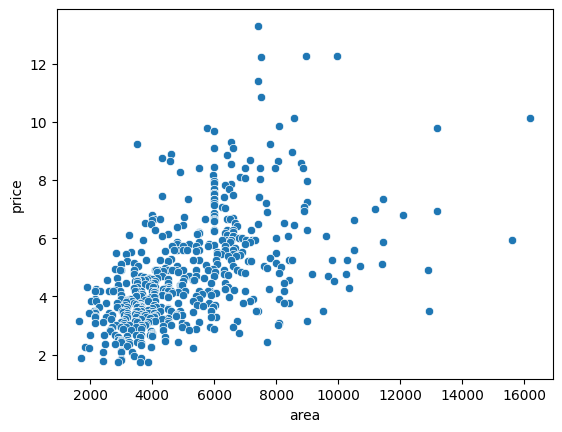

In [13]:
import seaborn as sns
sns.scatterplot(housing_data,x ="area", y = "price")

Split train/test « à la main » : seed(32) + choice 80/20 (théorie en S1_P2, étape 5).

In [14]:
np.random.seed(32)
housing_data["split"]= np.random.choice(["train","test"], size=len(housing_data),p=[0.8,0.2])

Vérification de la colonne split.

In [15]:
housing_data.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,split
0,13.300,7420,4,2,3,1,0,0,0,1,2,1,1.0,test
1,12.250,8960,4,4,4,1,0,0,0,1,3,0,1.0,train
2,12.250,9960,3,2,2,1,0,1,0,0,2,1,0.5,train
3,12.215,7500,4,2,2,1,0,1,0,1,3,1,1.0,test
4,11.410,7420,4,1,2,1,1,1,0,1,2,0,1.0,train
5,10.850,7500,3,3,1,1,0,1,0,1,2,1,0.5,test
6,10.150,8580,4,3,4,1,0,0,0,1,2,1,0.5,train
7,10.150,16200,5,3,2,1,0,0,0,0,0,0,0.0,test
8,9.870,8100,4,1,2,1,1,1,0,1,2,1,1.0,train
9,9.800,5750,3,2,4,1,1,0,0,1,1,1,0.0,train


Nuage coloré par split (hue) — vérifier la répartition homogène des points test.

<Axes: xlabel='area', ylabel='price'>

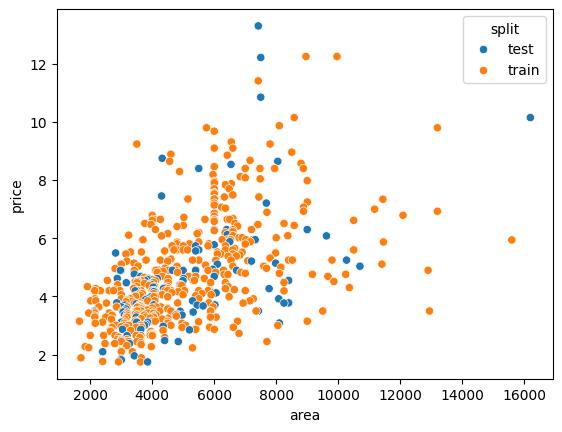

In [16]:
sns.scatterplot(housing_data,x ="area", y = "price", hue ="split")

Construction de train_data (filtre + drop split).

In [17]:
train_data = housing_data[housing_data["split"]=="train"].drop("split", axis = 1)

train_data

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
1,12.25000,8960,4,4,4,1,0,0,0,1,3,0,1.0
2,12.25000,9960,3,2,2,1,0,1,0,0,2,1,0.5
4,11.41000,7420,4,1,2,1,1,1,0,1,2,0,1.0
6,10.15000,8580,4,3,4,1,0,0,0,1,2,1,0.5
8,9.87000,8100,4,1,2,1,1,1,0,1,2,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
537,1.89000,1700,3,1,2,1,0,0,0,0,0,0,0.0
538,1.89000,3649,2,1,1,1,0,0,0,0,0,0,0.0
541,1.76715,2400,3,1,1,0,0,0,0,0,0,0,0.5
542,1.75000,3620,2,1,1,1,0,0,0,0,0,0,0.0


Imports sklearn (LinearRegression, mean_squared_error).

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

Création du modèle linéaire.

In [19]:
lr_one = LinearRegression()

X_train = tout sauf price (12 features) ; y_train = price. (Théorie de la régression à 12 variables + multicolinéarité : S2_P2, étape 8.)

In [20]:
X_train = train_data.drop("price",axis = 1)
y_train = train_data["price"]


Entraînement (moindres carrés matriciels).

In [21]:
lr_one.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Les 12 coefficients bruts — table de correspondance complète et lecture en S2_P2, étape 9 (rappel : hotwaterheating 0.77 et airconditioning 0.80 = les plus gros effets unitaires).

In [22]:
lr_one.coef_

array([2.40272977e-04, 1.17072468e-01, 8.60966462e-01, 5.08886333e-01,
       4.35349509e-01, 4.08107225e-01, 3.25309348e-01, 7.68713103e-01,
       7.99730379e-01, 2.57590676e-01, 5.67995150e-01, 3.66083651e-01])

## Here we start the ML course

Coefficient 1 (area ≈ 0.00024) — petit chiffre × grande échelle (milliers de m²).

In [23]:
slope = lr_one.coef_[0]
print(f"Slope :{slope}")

Slope :0.00024027297657413404


Coefficient 2 (bedrooms ≈ 0.117).

In [24]:
slope = lr_one.coef_[1]
print(f"Slope :{slope}")

Slope :0.11707246753121026


Coefficient 3 (bathrooms ≈ 0.861).

In [25]:
slope = lr_one.coef_[2]
print(f"Slope :{slope}")

Slope :0.8609664616730115


Coefficient 4 (stories ≈ 0.509). (Les 8 autres restent dans le tableau de la cellule coef_ !)

In [26]:
slope = lr_one.coef_[3]
print(f"Slope :{slope}")

Slope :0.5088863330190165


Intercept ≈ −0.196 : ancrage mathématique sans interprétation directe.

In [27]:
intercept = lr_one.intercept_
print(f"intercept : {intercept}")

intercept : -0.1957159016330845


Prédictions sur le train.

In [28]:
y_pred = lr_one.predict(X_train)

head() de référence pour la vérification manuelle (1re ligne : area=8960).

In [29]:
train_data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
1,12.25,8960,4,4,4,1,0,0,0,1,3,0,1.0
2,12.25,9960,3,2,2,1,0,1,0,0,2,1,0.5
4,11.41,7420,4,1,2,1,1,1,0,1,2,0,1.0
6,10.15,8580,4,3,4,1,0,0,0,1,2,1,0.5
8,9.87,8100,4,1,2,1,1,1,0,1,2,1,1.0


🔴 **Y_MANUAL : la vérification fausse** — 3 coefficients repris sur 12 ! Vraie prédiction ≈ 10.28 M, calcul manuel ≈ 5.87 M → **4.41 M d'écart**. Démonstration chiffrée complète en S2_P2, étape 10bis. *(Code non modifié.)*

In [30]:
Y_MANUAL = lr_one.coef_[0] * 8960 + lr_one.coef_[1] * 4 + lr_one.coef_[2] * 4 + lr_one.intercept_ 

In [31]:
Y_MANUAL

np.float64(5.869285685288043)

MAE train ≈ 0.778 M (formule en S1_P2, étape 14).

In [32]:
np.sum(np.abs(y_pred-y_train))/len(y_pred)

np.float64(0.7784244643823349)

RMSE train ≈ 1.049 M.

In [33]:
np.sqrt(mean_squared_error(y_pred,y_train))

np.float64(1.0492281677421402)

Préparation du test (mêmes 12 colonnes).

In [34]:
test_data = housing_data[housing_data["split"]=="test"].drop("split", axis = 1)
X_test = test_data.drop("price",axis = 1)
y_test = test_data["price"]

Prédictions test.

In [35]:
y_test_pred = lr_one.predict(X_test)

**RMSE test ≈ 1.112 M** — le tableau de progression 1→4→12 variables (1.71→1.32→1.11) est en S2_P2, étape 14.

In [36]:
np.sqrt(mean_squared_error(y_test_pred,y_test))

np.float64(1.1123777501840535)

Prix moyen du test ≈ 4.56 M → **erreur relative ≈ 24 %** (le bon réflexe pour juger une RMSE — S2_P2, étape 15).

In [37]:
np.mean(y_test)

np.float64(4.563775229357799)

Diagnostic réel-vs-prédit : le nuage le plus serré des notebooks maisons (cohérent avec la RMSE la plus basse).

<Axes: xlabel='price'>

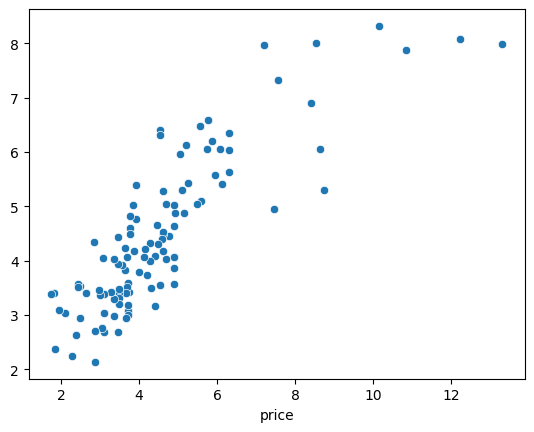

In [38]:
sns.scatterplot(x=y_test,y=y_test_pred)

## ⭐ Étape — L'arbre de régression sur les maisons

Import de `DecisionTreeRegressor` (théorie : split par réduction de variance, feuille = moyenne des prix — détail en S4_P4, étape 9).

In [39]:
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt

Arbre à `max_depth=2` : 4 feuilles max = 4 prix prédits possibles. Volontairement simple pour la lecture (avec 12 features disponibles, cet arbre n'en utilisera que 2 ou 3 — celles qui réduisent le plus la variance des prix).

In [40]:
dt = DecisionTreeRegressor(random_state=32,max_depth=2)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

Import de SuperTree.

In [41]:
from supertree import SuperTree

**Lecture de l'arbre (interactif) :** chaque nœud montre la question (ex : « area ≤ 5900 ? » ou « bathrooms ≤ 1.5 ? »), le nombre de maisons, et `value` = le **prix moyen** du groupe. Suis les branches : tu obtiens des règles du type « grande maison + 2 SDB → ~7.5 M ». (Mode d'emploi complet des arbres de régression : S4_P4, étape 11.)

In [42]:
super_tree = SuperTree(
    dt,
    X_train.values,
    y_train.values,
    list(X_train.columns),
)

super_tree.show_tree()

## ⭐ Étape — La recherche de profondeur CHIFFRÉE (remplace les 18 widgets !)

L'ancienne boucle affichait 18 arbres SuperTree (17 Mo de fichier !) — remplacée par une **mesure** : pour chaque `max_depth` de 1 à 49, entraîner un arbre et noter sa **RMSE sur le test**. C'est l'équivalent exact de la recherche du meilleur k du KNN, mais pour la profondeur d'arbre.

**🔍 Comment lire la courbe :** RMSE élevée à gauche (arbre trop simple = sous-apprentissage), un **creux** vers depth 4-6 (le bon compromis), puis une remontée/stagnation (surapprentissage : l'arbre mémorise le train, le test n'en profite plus). La « vallée » du compromis biais-variance, version arbres.

<Axes: xlabel='list_d'>

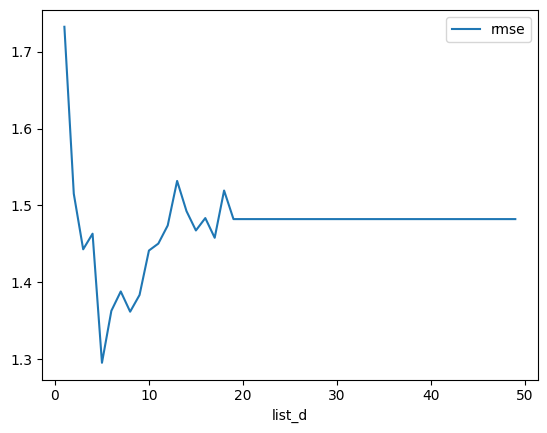

In [46]:
from sklearn.metrics import root_mean_squared_error


rmse = []
list_d = []
for i in range(1,50) :
    dt = DecisionTreeRegressor(max_depth=i,random_state=32)
    dt.fit(X_train, y_train)
    y_pred_tree = dt.predict(X_test)
    rmse.append(root_mean_squared_error(y_test,y_pred_tree))
    list_d.append(i)
df = pd.DataFrame({"list_d":list_d,"rmse" : rmse})
df.plot(x="list_d")

`df.min()` : la meilleure RMSE vaut **1.295** million (⚠️ et `list_d → 1.0` est juste la plus petite profondeur testée, pas la meilleure !).

💡 **Comparaison utile** : la régression linéaire à 12 variables faisait **1.11** sur le même test — l'arbre seul fait MOINS bien ici. Les relations prix/surface sont assez linéaires : la droite reste championne. (Les forêts aléatoires, plus tard, combleront l'écart.)

In [47]:
df.min()

list_d    1.000000
rmse      1.295373
dtype: float64

`idxmin()` → `rmse: 4` = ligne d'indice 4. Comme `list_d` démarre à 1, la ligne 4 = **profondeur 5**. L'arbre optimal a `max_depth=5` — le piège indice/valeur, encore lui (et bien déjoué si tu as lu ligne 4 → depth 5 !).

In [48]:
df.idxmin()

list_d    0
rmse      4
dtype: int64